In [3]:
import xarray as xr
import numpy as np
import cftime
import cmocean as cm
import matplotlib.pyplot as plt
import regionmask
from xmip.regionmask import merged_mask
import cartopy.crs as ccrs
import os
import pandas as pd

ERROR 1: PROJ: proj_create_from_database: Open of /global/homes/a/asubel/.conda/envs/NERSC_Kernel/share/proj failed


In [4]:
Pred_path = '/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-08-20_ConvNextUNetTrain3Dv021Eval3DEpochs70Epoch70_Train_global_3D_Test_global_3D_all_N_train_4000_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_4000_rand_seed_1.zarr'


In [5]:
def post_processor(ds: xr.Dataset, ds_truth: xr.Dataset, ls) -> xr.Dataset:
    """Converts the prediction output to an xarray dataset with the same dimensions/variables as input"""
    # Always run the ds_input_validate in non-deep mode here

    # correct swapped dimensions and warn
    if len(ds.x) == 180 and len(ds.y) == 360:
        ds = ds.rename({"x": "x_i", "y": "y_i"}).rename({"x_i": "y", "y_i": "x"})


    da = ds["__xarray_dataarray_variable__"]
    n_lev = 19
    if set(ls) - {"zos"} == set(["uo", "vo", "thetao", "so"]):
        variables = ["uo", "vo", "thetao", "so"]
    elif set(ls) - {"zos"} == set(["thetao", "so"]):
        variables = ["thetao", "so"]
    elif set(ls) - {"zos"} == set(["uo", "vo"]):
        variables = ["uo", "vo"]
    slices = [slice(i, i + n_lev) for i in range(0, len(variables) * n_lev, n_lev)]
    var_slices = {k: sl for k, sl in zip(variables, slices)}
    variables = {
        k: da.isel(var=sl).rename({"var": "lev"}) for k, sl in var_slices.items()
    }
    variables["zos"] = da.isel(var=-1).squeeze()

    ds_out = xr.Dataset(variables)
    for var in ds_out.data_vars:
        if "lev" in ds_out[var].dims:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask)
        else:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask.isel(lev=0))

    ## attach all coordinates from input
    ds_out = ds_out.assign_coords({co: ds_truth[co] for co in ds_truth.coords})

    return ds_out

levels = 19
emulation_stability=False
smooth = False

# OM4 v0.2.1
ds_input = xr.open_zarr(
    os.path.join("/pscratch/sd/s/suryad/data", "OM4_5daily_v0.2.1.zarr")
)

# Smooth the data 
if smooth:
    window = 10
    with ProgressBar():
        ds_input['uo'] = ds_input.uo.rolling(time=window, min_periods=1, center=False).mean().compute()
        ds_input['vo'] = ds_input.vo.rolling(time=window, min_periods=1, center=False).mean().compute()


# our groundtruth is always just a time slice of the training (training is a bad name

if emulation_stability:
    repeats = 100
    ds_groundtruth = ds_input.isel(lev=slice(None, levels))
    ds_groundtruth = ds_groundtruth.sel(time=slice("1996-01-01", "1996-12-31"))
    new_time = pd.date_range(start=str(ds_groundtruth.time[0].values), periods=repeats * len(ds_groundtruth.time), freq="5D")
    ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
    ds_groundtruth['time'] = new_time
    ds_groundtruth = ds_groundtruth.isel(time=slice(3, 7003))
else:
    ds_groundtruth = ds_input.isel(time=slice(4143, 4743)).isel(lev=slice(None, levels))


ls = ['uo', 'vo', 'thetao', 'so', 'zos'] #['uo', 'vo', 'thetao', 'so', 'zos'], ['thetao', 'so', 'zos']
output_folder = Pred_path.split("/")[-2].split("_Train")[0]
output_path = os.path.join("./temp", output_folder)

if os.path.isdir(output_path):
    print("Using Output Folder : ", output_path)
else:
    print("Using Output Folder : ../outputs")
    output_path = "../outputs"

ds_prediction_raw = xr.open_zarr(Pred_path)

# if emulation_stability:
#     ds_groundtruth = ds_groundtruth.isel(time=slice(0, ds_prediction_raw.time.size))

ds_prediction = post_processor(
    ds_prediction_raw, ds_groundtruth, ls
)

# Run the test to make sure the output is formatted correctly
ds_prediction = ds_prediction.transpose('time','lev',...)

Using Output Folder : ../outputs


In [6]:
data = xr.open_zarr("/pscratch/sd/s/suryad/data/OM4_5daily_v0.2.1.zarr")
time_slice = slice(ds_prediction['time'][0],ds_prediction['time'][-1])
data = data.sel(time = time_slice)

/tmp/ipykernel_373879/2263420567.py:3: UserWarning: `natural_earth_v4_1_0.ocean_basins_50` does not quite extend to 180°E - it's recommended to use `natural_earth_v5_1_2.ocean_basins_50` instead. See https://github.com/regionmask/regionmask/issues/410.
  basins = regionmask.defined_regions.natural_earth_v4_1_0.ocean_basins_50
/global/homes/a/asubel/.conda/envs/NERSC_Kernel/lib/python3.12/site-packages/regionmask/core/mask.py:179: FutureWarning: Passing 'lon_name' and 'lat_name' was deprecated in v0.10.0. Please pass the coordinates directly, e.g., `mask*(ds[lon_name], ds[lat_name])`.
  warnings.warn(


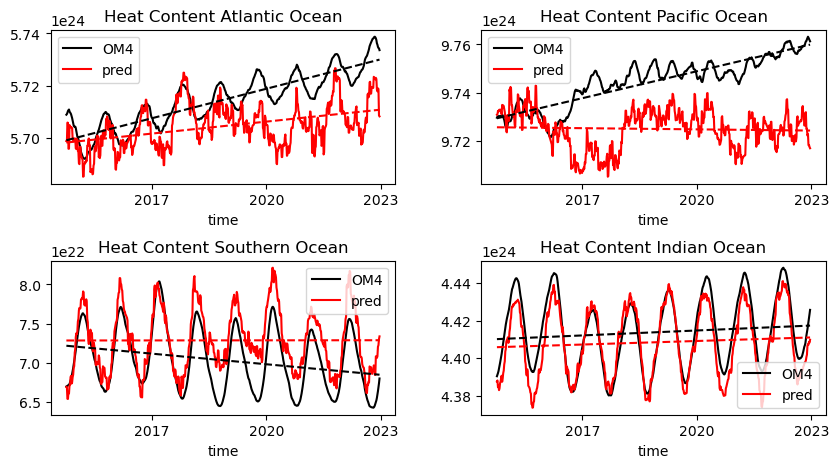

In [7]:
# Compute Basin Heat Content Time Series

basins = regionmask.defined_regions.natural_earth_v4_1_0.ocean_basins_50

mask = merged_mask(basins,data)

atlantic_mask = xr.where(np.logical_or(mask == 0,mask == 1),1.0,np.nan)
pacific_mask = xr.where(np.logical_or(mask == 2,mask == 3),1.0,np.nan)
southern_ocean_mask = xr.where(mask == 7,1.0,np.nan)
indian_ocean_mask = xr.where(mask == 5,1.0,np.nan)

masks = atlantic_mask.to_dataset(name='Atlantic')
masks['Pacific']  = pacific_mask
masks['Southern'] = southern_ocean_mask
masks['Indian'] = indian_ocean_mask

c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3

fig, ax = plt.subplots(2,2,figsize=(10,5),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [1,1], 'wspace': 0.25,'hspace':.5})
ax_flat = ax.flatten()

for i, var in enumerate(list(masks.keys())):
    OHC_pred = ((ds_prediction['thetao']*c_p*rho_0*masks[var])*ds_prediction['areacello']*ds_prediction['dz']).sum(['x','y','lev'])    
    OHC = ((data['thetao']*c_p*rho_0*masks[var])*ds_prediction['areacello']*ds_prediction['dz']).sum(['x','y','lev'])

    OHC.plot(ax = ax_flat[i], label = 'OM4',c = 'k')
    OHC_pred.plot(ax = ax_flat[i], label = 'pred', c = 'r')
    ax_flat[i].legend()
    ax_flat[i].set_title("Heat Content " + var + " Ocean")
    coeffs_OHC_trend = np.polyfit(np.arange(OHC.size), OHC, 1)
    coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred.size), OHC_pred, 1)
    ax_flat[i].plot(OHC.time.data, np.arange(OHC.size)*coeffs_OHC_trend[0] + coeffs_OHC_trend[1],c = 'k', ls = '--')
    ax_flat[i].plot(OHC_pred.time.data, np.arange(OHC_pred.size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = 'r', ls = '--')

# fig.savefig('./figures/OHC_Short.png',dpi=250)

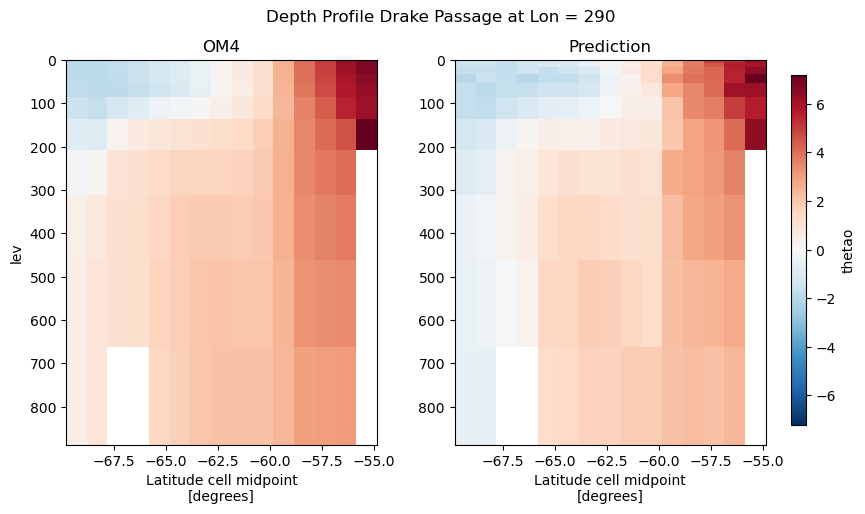

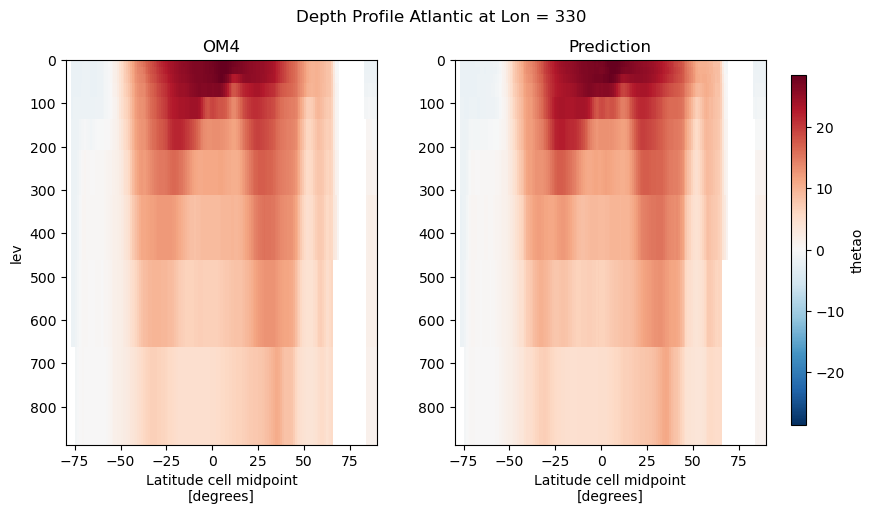

In [33]:
#Drake Passage Full Depth 

day_start = 590
window = 3
regions = {'Drake Passage': {'lon': 290, 'lat_bnds':slice(-70,-55)},
           'Atlantic': {'lon': 330, 'lat_bnds':slice(-80,90)}}
surface = True

for region in ['Drake Passage', 'Atlantic']:
    fig, ax = plt.subplots(1,2,figsize=(10,5),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [1], 'wspace': 0.25,'hspace':.5})
    bounds = regions[region]
    var = 'thetao'
    if surface:
        level_slice = slice(0,1000)
    else:
        level_slice = slice(None)
    


    data[var].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'],lev = level_slice).isel(time = slice(day_start,day_start+window)).mean('time').plot(ax=ax[0],add_colorbar=False)
    ax[0].invert_yaxis()
    ax[0].set_title('OM4')

    pred_plot = ds_prediction[var].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'],lev = level_slice).isel(time = slice(day_start,day_start+window)).mean('time').plot(ax=ax[1],add_colorbar=False)
    ax[1].invert_yaxis()
    ax[1].set_ylabel('')
    ax[1].set_title('Prediction')

    fig.subplots_adjust(right=0.825)
    cbar_ax = fig.add_axes([0.85, 0.15, 0.015, 0.7])
    cbar = fig.colorbar(pred_plot, cax=cbar_ax)
    cbar.set_label(var,rotation = 90)
    fig.suptitle(r"Depth Profile " +region + " at Lon = " + str(bounds['lon']) )

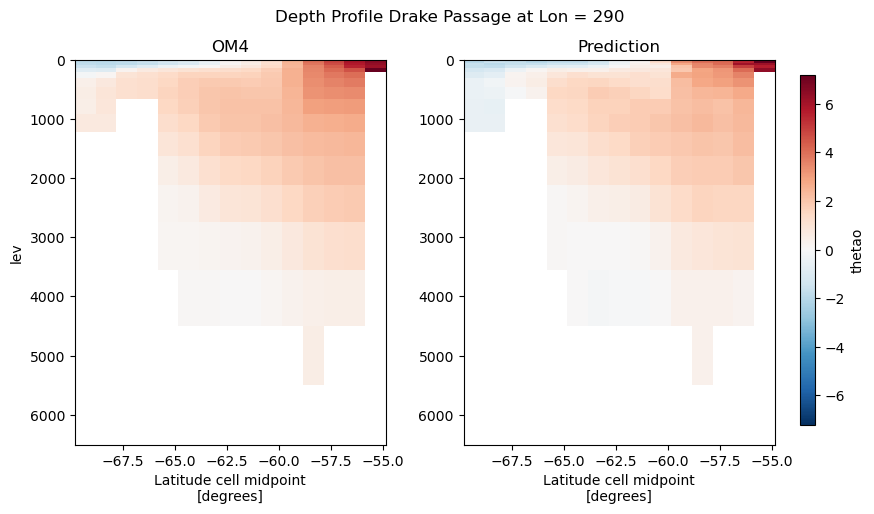

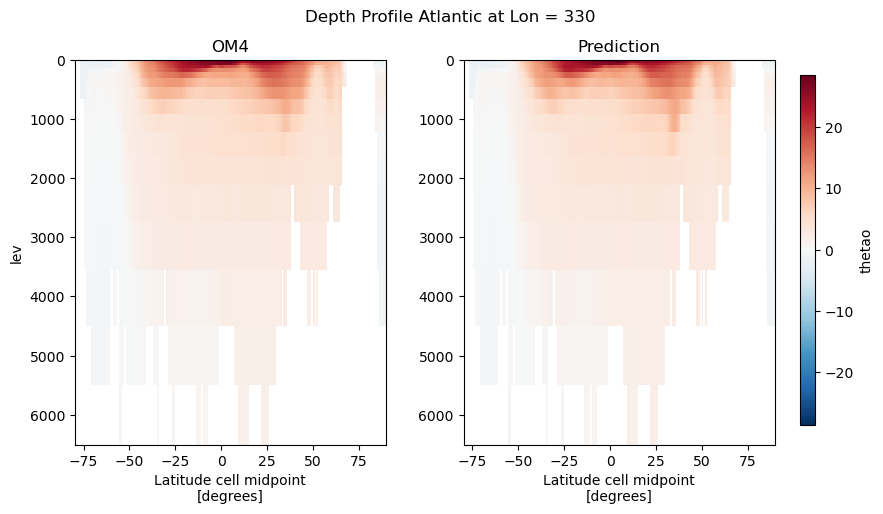

In [34]:
#Drake Passage Full Depth 

day_start = 590
window = 3
regions = {'Drake Passage': {'lon': 290, 'lat_bnds':slice(-70,-55)},
           'Atlantic': {'lon': 330, 'lat_bnds':slice(-80,90)}}
surface = False

for region in ['Drake Passage', 'Atlantic']:
    fig, ax = plt.subplots(1,2,figsize=(10,5),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [1], 'wspace': 0.25,'hspace':.5})
    bounds = regions[region]
    var = 'thetao'
    if surface:
        level_slice = slice(0,1000)
    else:
        level_slice = slice(None)
    


    data[var].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'],lev = level_slice).isel(time = slice(day_start,day_start+window)).mean('time').plot(ax=ax[0],add_colorbar=False)
    ax[0].invert_yaxis()
    ax[0].set_title('OM4')

    pred_plot = ds_prediction[var].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'],lev = level_slice).isel(time = slice(day_start,day_start+window)).mean('time').plot(ax=ax[1],add_colorbar=False)
    ax[1].invert_yaxis()
    ax[1].set_ylabel('')
    ax[1].set_title('Prediction')

    fig.subplots_adjust(right=0.825)
    cbar_ax = fig.add_axes([0.85, 0.15, 0.015, 0.7])
    cbar = fig.colorbar(pred_plot, cax=cbar_ax)
    cbar.set_label(var,rotation = 90)
    fig.suptitle('Depth Profile ' +region + ' at Lon = ' + str(bounds['lon']))

In [35]:
clim = xr.open_zarr('./Climatology/clim_to_2014_500m.zarr').load()
clim_as_pred = xr.open_zarr('./Climatology/clim_as_pred_2014_500m.zarr')
data_surface = data.sel(lev = slice(0,500))
ds_prediction_surface = ds_prediction.sel(lev = slice(0,500))
clim_pred = ds_prediction_surface['thetao'].groupby('time.dayofyear').mean().compute()


In [36]:
def NinoIndexComputeClim(T,area,dt = 5, window = 150):
    T_clim = T.copy()
    T_clim = T_clim.sel(x = slice(118,260), y = slice(-5,5))
    area = area.sel(x = slice(118,260), y = slice(-5,5))
    clim = T_clim.groupby('time.dayofyear').mean('time')
    window = int(window/dt)
    for i, t in enumerate(T_clim.time.values):
        day = int(t.dayofyr)
        T_clim[i] = (T[i]-clim.sel(dayofyear=day)).data        

    T_clim = T_clim.rolling(time = window).mean()
    T_clim = (T_clim*area).sum(["x","y"])/area.sum(["x","y"])

    return T_clim[window:]


In [37]:
nino_pred_compute_clim = NinoIndexComputeClim(ds_prediction_surface['thetao'][:,0],ds_prediction['areacello'])
time_slice = slice(ds_prediction['time'][0],ds_prediction['time'][-1])
nino_true_compute_clim = NinoIndexComputeClim(data_surface['thetao'].sel(time=time_slice)[:,0],ds_prediction['areacello'],)

In [2]:
day_max = int((np.argwhere(nino_pred_compute_clim.values == np.nanmax(nino_pred_compute_clim.values)) + 30).squeeze())
day_min = int((np.argwhere(nino_pred_compute_clim.values == np.nanmin(nino_pred_compute_clim.values)) + 30).squeeze())

NameError: name 'np' is not defined

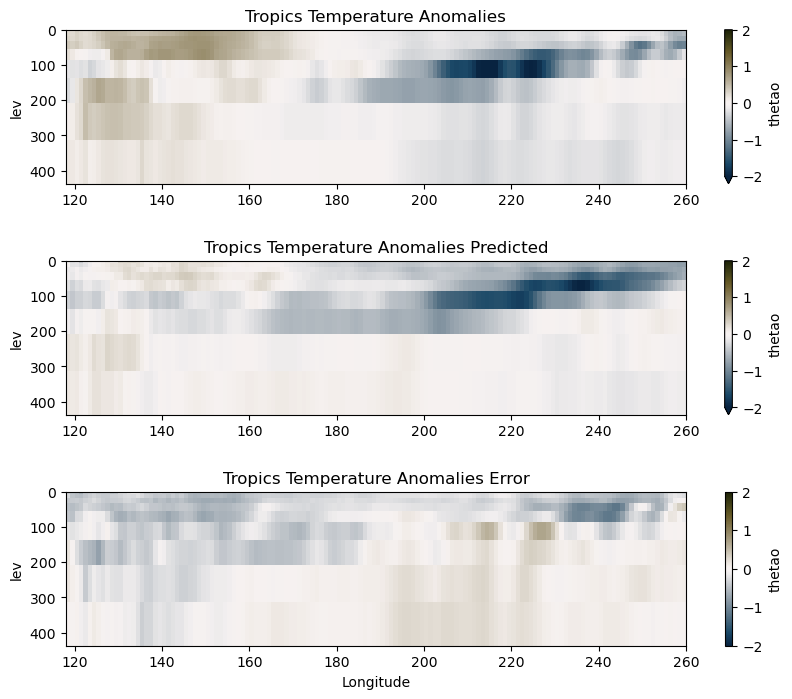

In [38]:

fig,axs = plt.subplot_mosaic([['time series','time series'],['nino_true','nina_true'],['nino_pred','nina_pred']],figsize = (10,6),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [.6,.5,.5], 'wspace': 0.25,'hspace':.5})
nino_pred_compute_clim.plot(label = 'Prediction', c = 'r',ax = axs['time series'])
nino_true_compute_clim.plot(label = 'OM4', c = 'k',ax = axs['time series'])
nino_pred_compute_clim.isel(time = slice(day_max-30,day_max-30+1)).drop_vars(['dz','lev']).plot.scatter(s = 80, c = 'b',ax = axs['time series'])
nino_pred_compute_clim.isel(time = slice(day_min-30,day_min-30+1)).drop_vars(['dz','lev']).plot.scatter(s = 80, c = 'b',ax = axs['time series'])

axs['time series'].legend()
axs['time series'].set_title('Nino 3.4 Index')

day_start = day_max
window = 3

time_slice = slice(ds_prediction['time'][day_start],ds_prediction['time'][day_start+window])
times = ds_prediction['time'][day_start:day_start+window].data
days_of_year = [i.dayofyr for i in times]
pred_clim_to_remove = clim_pred.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
pred_clim_to_remove['time'] = times

tropics_profile = (data_surface['thetao'].sel(time = time_slice,x = slice(118,260), y = slice(-5,5))-clim_as_pred['thetao'][day_start:day_start+window].sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile_pred = (ds_prediction_surface['thetao'][day_start:day_start+window].sel(lev = slice(0,500),x = slice(118,260), y = slice(-5,5))-pred_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])


tropics_profile.plot.pcolormesh(ax = axs['nino_true'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2)
axs['nino_true'].set_title('Nino Anomalies OM4')
axs['nino_true'].set_xlabel('')
axs['nino_true'].invert_yaxis()
tropics_profile_pred.plot.pcolormesh(ax = axs['nino_pred'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2)
axs['nino_pred'].set_title('Nino Anomalies Predicted')
axs['nino_pred'].set_xlabel('')
axs['nino_pred'].invert_yaxis()


axs['time series'].legend()

day_start = day_min
window = 3

time_slice = slice(ds_prediction['time'][day_start],ds_prediction['time'][day_start+window])
times = ds_prediction['time'][day_start:day_start+window].data
days_of_year = [i.dayofyr for i in times]
pred_clim_to_remove = clim_pred.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
pred_clim_to_remove['time'] = times

tropics_profile = (data_surface['thetao'].sel(time = time_slice,x = slice(118,260), y = slice(-5,5))-clim_as_pred['thetao'][day_start:day_start+window].sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile_pred = (ds_prediction_surface['thetao'][day_start:day_start+window].sel(lev = slice(0,500),x = slice(118,260), y = slice(-5,5))-pred_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])


tropics_profile.plot.pcolormesh(ax = axs['nina_true'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2)
axs['nina_true'].set_title('Nina Anomalies OM4')
axs['nina_true'].set_xlabel('')
axs['nina_true'].invert_yaxis()
tropics_profile_pred.plot.pcolormesh(ax = axs['nina_pred'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2)
axs['nina_pred'].set_title('Nina Anomalies Predicted')
axs['nina_pred'].set_xlabel('')
axs['nina_pred'].invert_yaxis()
